In [95]:
import numpy as np
import numpy.linalg as linal
import pandas as pd
import sympy

---
# <u>Part A :</u>
Creating a OLS regression line for the provided data
## <u>Nonlinear to Linear equation Conversion</u>
* The independent variable **X** is **1/T**
* The dependent variable **Y** is **ln(P)**

## OLS Model
$$ \ln(P) = \beta_0 + \beta_1\cdot \frac{1}{T} $$

In [96]:
df1 = pd.read_csv(r'Assignment2/vpdata.txt',sep=',')
df1["lnP"] = np.log(df1.iloc[:,1])
df1["1/T"] = df1.iloc[:,0]**-1
df1

,Temperature,Pressure,lnP,1/T
0,274.74978,42.068686,3.739304,0.003640
1,257.60110,22.829599,3.128058,0.003882
2,282.38801,55.867600,4.022985,0.003541
3,288.21548,70.936874,4.261790,0.003470
4,266.93534,33.139607,3.500729,0.003746
...,...,...,...,...
95,297.72529,94.355942,4.547074,0.003359
96,256.50485,19.314426,2.960852,0.003899
97,255.44508,18.838659,2.935911,0.003915
98,296.10036,94.768984,4.551442,0.003377


In [97]:
N = 100
p = 1
dft = df1.copy()
iter = 0

while True :
    print('-------------------',iter+1,'---------------------')
    mean_shifted = dft - dft.mean()
    X = np.transpose(np.matrix(dft.iloc[:,3]))                     # 100 x 1
    y = np.transpose(np.matrix(dft.iloc[:,2]))       # 100 x 1
    Xms = np.transpose(np.matrix(mean_shifted.iloc[:,3]))          # 100 x 1
    
    yms = y - y.mean()

    beta = linal.inv(np.transpose(Xms)*Xms)*np.transpose(Xms)*yms
    beta0= y.mean() - np.matrix(dft.iloc[:,3].mean())*beta

    print(beta, beta0)
    error = y - X*beta - beta0
    estimate_variance =  np.transpose(error)*error/(N-p-1)
    R2 = 1 - estimate_variance*(N-p-1)/(dft['lnP'].var()*N)
    print("R2 value            : ", R2[0,0])

    break

------------------- 1 ---------------------
[[-2837.28609028]] [[14.09731181]]
R2 value            :  0.9887994168783533


In [98]:
y_estimate = np.exp(y - error)
E = np.transpose(np.matrix(df1['Pressure'])) - y_estimate
SSE = np.transpose(E)*E
SST = df1['Pressure'].var()*N
print("F                  :",1 - (SSE[0,0]/SST))
print(SSE, SST)

F                  : 0.9952784301912683
[[372.42291591]] 78876.92674167418


In [99]:
yhat = np.transpose(y-error).tolist()[0]
xs, ys = zip(*sorted(zip(df1["1/T"], yhat)))

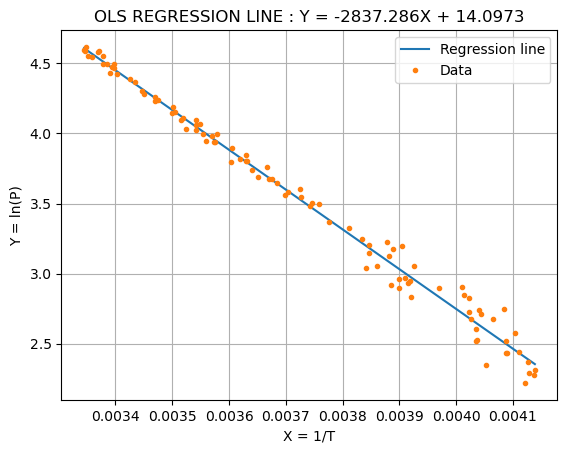

In [100]:
import matplotlib.pyplot as plt

plt.plot(xs,ys)
plt.plot(df1["1/T"],y,'.')
plt.legend(['Regression line','Data'])
plt.xlabel('X = 1/T')
plt.ylabel('Y = ln(P)')
plt.grid()
plt.title(f'OLS REGRESSION LINE : Y = {beta[0,0]:.3f}X + {beta0[0,0]:.4f}')
plt.show()

In [101]:
xs, ys = zip(*sorted(zip(df1["Temperature"], np.transpose(y_estimate).tolist()[0])))

In [102]:
np.exp(beta0)

matrix([[1325515.24869381]])

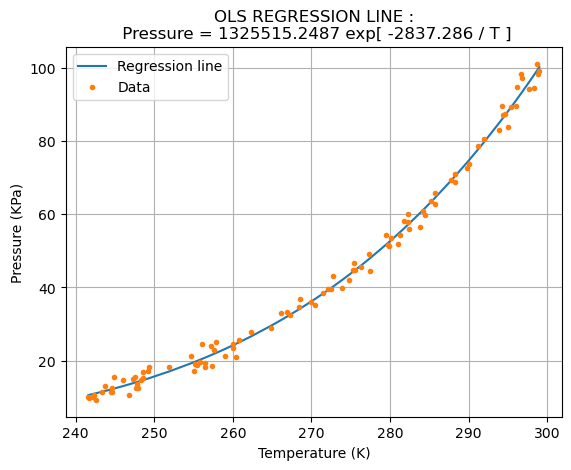

In [103]:
plt.plot(xs,ys)
plt.plot(df1["Temperature"],df1["Pressure"],'.')
plt.legend(['Regression line','Data'])
plt.xlabel('Temperature (K)')
plt.ylabel('Pressure (KPa)')
plt.grid()
plt.title(f'OLS REGRESSION LINE :\n Pressure = {np.exp(beta0)[0,0]:.4f} exp[ {beta[0,0]:.3f} / T ]')
plt.show()

---
# <u>Part B :</u>
Creating a regression model with **$P_{sat}$** as dependent variable and **$T$** , **$T^2$** as independent variables
the polynomial model is taken as 
$$P_{sat} = \beta_0 + \beta_1\cdot T + \beta_2\cdot T^2$$

In [104]:
df = pd.read_csv(r'Assignment2/vpdata.txt',sep=',')
Temperature = df.iloc[:,0]
Pressure = df.iloc[:,1]
Temperature2 = df.iloc[:,0]**2
df["Temperature2"] = Temperature2
df["Temperature3"] = df.iloc[:,0]**3
df["Temperature4"] = df.iloc[:,0]**4
df["Temperature5"] = df.iloc[:,0]**5
df

,Temperature,Pressure,Temperature2,Temperature3,Temperature4,Temperature5
0,274.74978,42.068686,75487.441610,2.074016e+07,5.698354e+09,1.565621e+12
1,257.60110,22.829599,66358.326721,1.709398e+07,4.403428e+09,1.134328e+12
2,282.38801,55.867600,79742.988192,2.251846e+07,6.358944e+09,1.795690e+12
3,288.21548,70.936874,83068.162912,2.394153e+07,6.900320e+09,1.988779e+12
4,266.93534,33.139607,71254.475741,1.902034e+07,5.077200e+09,1.355284e+12
...,...,...,...,...,...,...
95,297.72529,94.355942,88640.348306,2.639047e+07,7.857111e+09,2.339261e+12
96,256.50485,19.314426,65794.738074,1.687667e+07,4.328948e+09,1.110396e+12
97,255.44508,18.838659,65252.188896,1.666835e+07,4.257848e+09,1.087646e+12
98,296.10036,94.768984,87675.423192,2.596072e+07,7.686980e+09,2.276117e+12


In [105]:
N = 100
p = 2
dft = df.copy()
iter = 0

while True :
    print('-------------------',iter+1,'---------------------')
    mean_shifted = dft - dft.mean()
    X = np.matrix(dft.iloc[:,[0,2]])                    # 31 x 4
    y = np.transpose(np.matrix(dft.iloc[:,1]))              # 31 x 1
    Xms = np.matrix(mean_shifted.iloc[:,[0,2]])          # 31 x 4
    
    yms = y - y.mean()

    beta = linal.inv(np.transpose(Xms)*Xms)*np.transpose(Xms)*yms
    beta0= y.mean() - np.matrix(dft.iloc[:,[0,2]].mean())*beta

    error = y - X*beta - beta0
    estimate_variance =  np.transpose(error)*error/(N-p-1)
    R2_RM = 1 - estimate_variance*(N-p-1)/(y.var()*N)
    print("R2 value            : ", R2_RM[0,0])

    print(beta, beta0)
    break


------------------- 1 ---------------------
R2 value            :  0.9943635507559685
[[-10.93216772]
 [  0.02302386]] [[1309.31475908]]


In [106]:
SSE = np.transpose(error)*error
SST = df1['Pressure'].var()*N
print("F                  :",1 - (SSE[0,0]/SST))
print(SSE, SST)

F                  : 0.9944199152484088
[[440.13993616]] 78876.92674167418


In [107]:
yhat = np.transpose(y-error).tolist()[0]
xs, ys = zip(*sorted(zip(Temperature, yhat)))

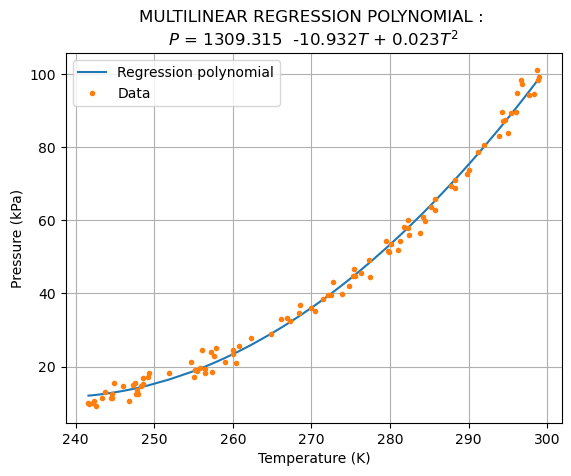

In [108]:
plt.plot(xs,ys)
plt.plot(Temperature,y,'.')
plt.legend(['Regression polynomial','Data'])
plt.ylabel('Pressure (kPa)')
plt.xlabel('Temperature (K)')
plt.title(f"MULTILINEAR REGRESSION POLYNOMIAL : \n$P$ = {beta0[0,0]:.3f}  {beta[0,0]:.3f}$T$ + {beta[1,0]:.3f}$T^2$")
plt.grid()
plt.show()

---
## Caculating regression model assuming the model to be of 5th order 
$$ P_{sat} = \beta_0 + \beta_1\cdot T + \beta_2\cdot T^2 + \beta_3\cdot T^3 + \beta_4\cdot T^4 + \beta_5\cdot T^5$$

In [109]:
df

,Temperature,Pressure,Temperature2,Temperature3,Temperature4,Temperature5
0,274.74978,42.068686,75487.441610,2.074016e+07,5.698354e+09,1.565621e+12
1,257.60110,22.829599,66358.326721,1.709398e+07,4.403428e+09,1.134328e+12
2,282.38801,55.867600,79742.988192,2.251846e+07,6.358944e+09,1.795690e+12
3,288.21548,70.936874,83068.162912,2.394153e+07,6.900320e+09,1.988779e+12
4,266.93534,33.139607,71254.475741,1.902034e+07,5.077200e+09,1.355284e+12
...,...,...,...,...,...,...
95,297.72529,94.355942,88640.348306,2.639047e+07,7.857111e+09,2.339261e+12
96,256.50485,19.314426,65794.738074,1.687667e+07,4.328948e+09,1.110396e+12
97,255.44508,18.838659,65252.188896,1.666835e+07,4.257848e+09,1.087646e+12
98,296.10036,94.768984,87675.423192,2.596072e+07,7.686980e+09,2.276117e+12


In [110]:
N = 100
p = 5
dft = df.copy()
iter = 0

while True :
    print('-------------------',iter+1,'---------------------')
    mean_shifted = dft - dft.mean()
    X = np.matrix(dft.iloc[:,[0,2,3,4,5]])                    # 31 x 4
    y = np.transpose(np.matrix(dft.iloc[:,1]))              # 31 x 1
    Xms = np.matrix(mean_shifted.iloc[:,[0,2,3,4,5]])          # 31 x 4
    
    yms = y - y.mean()

    beta = linal.inv(np.transpose(Xms)*Xms)*np.transpose(Xms)*yms
    beta0= y.mean() - np.matrix(dft.iloc[:,[0,2,3,4,5]].mean())*beta
    error = y - X*beta - beta0

    estimate_variance =  np.transpose(error)*error/(N-p-1)
    # R2_FM = 1 - estimate_variance*(N-p-1)/(y.var()*N)
    R2_FM = 1 - np.transpose(error)*error/(dft["Pressure"].var()*N)
    print("R2 value            : ", R2_FM[0,0])

    print(beta, beta0)
    break

------------------- 1 ---------------------
R2 value            :  0.9953248141780824
[[ 1.18008668e+03]
 [-8.54930771e+00]
 [ 3.09912439e-02]
 [-5.63054029e-05]
 [ 4.11403852e-08]] [[-65145.36545611]]


In [111]:
yhat = np.transpose(y-error).tolist()[0]
xs, ys = zip(*sorted(zip(Temperature, yhat)))

In [112]:
SSE = np.transpose(error)*error
SST = df1['Pressure'].var()*N
print("F                  :",1 - (SSE[0,0]/SST))
print(SSE, SST)

F                  : 0.9953248141780824
[[368.76428958]] 78876.92674167418


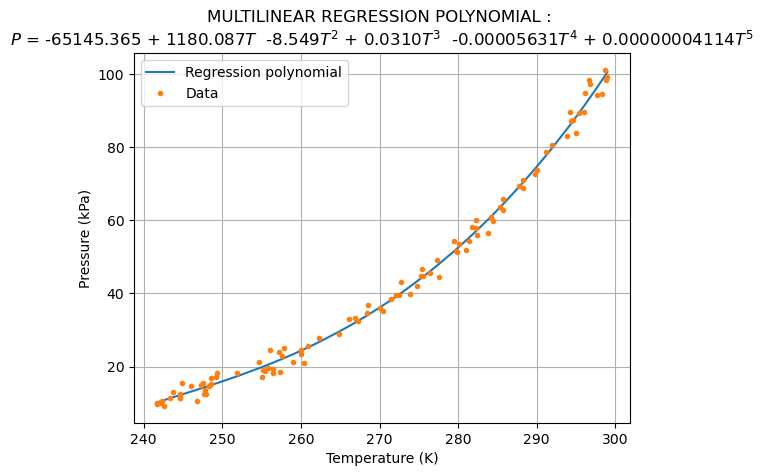

In [113]:
plt.plot(xs,ys)
plt.plot(Temperature,y,'.')
plt.legend(['Regression polynomial','Data'])
plt.ylabel('Pressure (kPa)')
plt.xlabel('Temperature (K)')
plt.title(f"MULTILINEAR REGRESSION POLYNOMIAL : \n$P$ = {beta0[0,0]:.3f} + {beta[0,0]:.3f}$T$  {beta[1,0]:.3f}$T^2$ + {beta[2,0]:.4f}$T^3$  {beta[3,0]:.8f}$T^4$ + {beta[4,0]:.11f}$T^5$")
plt.grid()
plt.show()

---

# <u>Part C :</u>

In [114]:
print("R2 for linear model             :", R2[0,0])
print("R2 for quadratic model          :", R2_RM[0,0])
print("R2 for 5th order polynomial fit :", R2_FM[0,0])

print(R2_FM, R2_RM)

R2 for linear model             : 0.9887994168783533
R2 for quadratic model          : 0.9943635507559685
R2 for 5th order polynomial fit : 0.9953248141780824
[[0.99532481]] [[0.99436355]]


In [115]:
F = (94/3)*(R2_RM[0,0] - R2_FM[0,0])/(R2_FM[0,0] - 1)
print(F)

6.4424363808241285


## As F is more than 2.45 ( the value corresponding to 95% confidence interval in F distribution )
## it tells that the reduced model is enough to represent the data 

This value of F is computed between the 5th order polynomial **Full Model** and the 2nd order polynomial **Reduced Model**\
So from the F value we can say that the 2nd order polynomial is sufficient to represent the data